# Winter Storm Uri: Impact Analysis

On February 15–20, 2021, Winter Storm Uri knocked out generation across Texas, pushing wholesale prices to ERCOT's $9,000/MWh cap. This notebook simulates what happened to real customers across different contract types (fixed, variable, indexed) using actual Pecan Street consumption data and real Power to Choose plans from October 2019.

Comparison to recent period (June 2026) shows how markets have stabilized post-Uri.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

from txpower.ercot_prices import load_engie_hourly_csv, synthetic_uri_spp
from txpower.cost_engine import simulate_month
from txpower.models import Contract, RateType, TduCharges

class blogstyle:
    PALETTE = ["#2A6F7E", "#FF3F86", "#7281C2", "#FFA175", "#00BAAC", "#484848"]
    @staticmethod
    def title(ax, title, subtitle=""):
        ax.set_title(f"{title}\n{subtitle}" if subtitle else title, fontsize=12, fontweight="bold")
    @staticmethod
    def save(fig, name):
        pass

print("✓ Imports complete")

✓ Imports complete


In [2]:
ptc_csv = ROOT / "data/raw/ptc_offers_20191001.csv"
plans_df = pd.read_csv(ptc_csv)
print(f"Loaded {len(plans_df)} plans from Oct 2019 Power to Choose")
print(f"\nRate type breakdown:")
print(plans_df["[RateType]"].value_counts())

Loaded 1915 plans from Oct 2019 Power to Choose

Rate type breakdown:
[RateType]
Fixed       1710
Variable     194
Indexed       10
Name: count, dtype: int64


In [3]:
from pathlib import Path

raw_dir = ROOT / "data" / "raw"
ps_files_feb2021 = list(raw_dir.glob("*pecan*2021*"))
ps_csv = ps_files_feb2021[0] if ps_files_feb2021 else raw_dir / "pecan_street_15min_austin.csv"
data_period = "Feb 2021" if ps_files_feb2021 else "2018 (as proxy)"

ps_df = pd.read_csv(ps_csv, usecols=["dataid", "local_15min", "grid"])
ps_df["local_15min"] = pd.to_datetime(ps_df["local_15min"], utc=True).dt.tz_convert("America/Chicago")

print(f"Loaded {len(ps_df)} consumption records ({data_period})")
print(f"Unique homes: {ps_df['dataid'].nunique()}")
print(f"Date range: {ps_df['local_15min'].min()} to {ps_df['local_15min'].max()}")

Loaded 873286 consumption records (2018 (as proxy))
Unique homes: 25
Date range: 2018-01-01 00:00:00-06:00 to 2018-12-31 23:45:00-06:00


In [4]:
from txpower.ercot_prices import load_spp_annual_xlsx, find_ercot_2021_file

spp_real = None
data_source = None

ercot_file = find_ercot_2021_file()
if ercot_file:
    try:
        spp_real = load_spp_annual_xlsx(ercot_file, settlement_point="LZ_NORTH")
        data_source = f"ERCOT 2021 SPP xlsx ({ercot_file.name})"
        print(f"✓ Loaded real ERCOT SPP: {len(spp_real)} records")
    except Exception as e:
        print(f"⚠ Could not load ERCOT xlsx: {e}")
        spp_real = None

spp_synthetic = synthetic_uri_spp()
if spp_real is None:
    print(f"ℹ Using synthetic Uri prices for full Feb 1-28")
    data_source = "Synthetic SPP (documented Uri scenario)"
else:
    print(f"✓ Data source: {data_source}")

print(f"✓ Loaded synthetic Uri prices: {len(spp_synthetic)} records (Feb 1-28, fallback)")

✓ Loaded real ERCOT SPP: 35036 records
✓ Data source: ERCOT 2021 SPP xlsx (rpt.00013061.0000000000000000.RTMLZHBSPP_2021.xlsx)
✓ Loaded synthetic Uri prices: 2688 records (Feb 1-28, fallback)


In [5]:
home_groups = ps_df.groupby("dataid")["grid"].sum().sort_values(ascending=False)
active_homes = home_groups[home_groups > 100].index.tolist()
sample_homes = active_homes

print(f"Found {len(sample_homes)} net-consumer homes")
print(f"\nHome consumption summary:")
for home_id in sample_homes[:5]:
    total = ps_df[ps_df["dataid"] == home_id]["grid"].sum()
    print(f"  Home {home_id}: {total:.0f} kWh")
print(f"  ... ({len(sample_homes) - 5} more homes)")

Found 24 net-consumer homes

Home consumption summary:
  Home 9922: 68696 kWh
  Home 3039: 51460 kWh
  Home 8565: 47037 kWh
  Home 7901: 45759 kWh
  Home 8156: 43939 kWh
  ... (19 more homes)


In [6]:
def get_feb_2021_usage(home_id: int) -> pd.Series:
    """Extract Feb 2021 usage for a home (real data first, proxy if not available)."""
    home_data = ps_df[ps_df["dataid"] == home_id].copy()
    
    if home_data.empty:
        return None
    
    feb_data = home_data[
        (home_data["local_15min"].dt.month == 2) &
        (home_data["local_15min"].dt.year == 2021)
    ].copy()
    
    if feb_data.empty:
        feb_data = home_data[
            (home_data["local_15min"].dt.month == 3) &
            (home_data["local_15min"].dt.year == 2018)
        ].copy()
        data_note = "March 2018 proxy"
    else:
        data_note = "Real Feb 2021"
    
    if feb_data.empty:
        return None
    
    feb_data["kwh"] = feb_data["grid"] * (15 / 60)
    feb_data = feb_data.set_index("local_15min").sort_index()
    usage = feb_data["kwh"].resample("h").sum()
    
    naive_index = usage.index.tz_localize(None)
    if data_note == "March 2018 proxy":
        feb_index = pd.to_datetime(
            naive_index.strftime('%Y-02-01')
        ) + pd.to_timedelta(naive_index.day - 1, unit='D')
        feb_index = feb_index.map(lambda x: x.replace(year=2021))
    else:
        feb_index = naive_index.map(lambda x: x.replace(year=2021))
    
    usage.index = feb_index.tz_localize("America/Chicago", ambiguous=True, nonexistent='shift_forward')
    usage.attrs['data_source'] = data_note
    
    return usage

usages = {}
data_sources = {}
for home_id in sample_homes:
    usage = get_feb_2021_usage(home_id)
    if usage is not None:
        usages[home_id] = usage
        data_sources[home_id] = usage.attrs.get('data_source', 'unknown')

print(f"Prepared usage data for {len(usages)} homes")
print(f"Usage index tz: {list(usages.values())[0].index.tz}")

Prepared usage data for 24 homes
Usage index tz: America/Chicago


In [7]:
def ptc_row_to_contract(row) -> Contract:
    """Convert PTC export row to Contract object."""
    rate_type_map = {"Fixed": RateType.FIXED, "Variable": RateType.VARIABLE, "Indexed": RateType.INDEXED}
    
    return Contract(
        rep_name=row["[RepCompany]"],
        plan_name=row["[Product]"],
        rate_type=rate_type_map.get(row["[RateType]"], RateType.FIXED),
        term_months=int(row["[TermValue]"]) if pd.notna(row["[TermValue]"]) else 12,
        energy_charge_per_kwh=float(row["[kwh1000]"]),
        base_monthly_charge=0.0,
        tdu=TduCharges("Oncor", 4.23, 0.038),
        indexed_adder_per_kwh=0.010 if rate_type_map.get(row["[RateType]"]) == RateType.INDEXED else None,
        avg_price_500=float(row["[kwh500]"]) if pd.notna(row["[kwh500]"]) else None,
        avg_price_1000=float(row["[kwh1000]"]),
        avg_price_2000=float(row["[kwh2000]"]) if pd.notna(row["[kwh2000]"]) else None,
        efl_source_file="Wayback Oct 1, 2019",
    )

np.random.seed(42)
contracts = []
for _, row in plans_df.iterrows():
    contracts.append(ptc_row_to_contract(row))

print(f"Created {len(contracts)} Contract objects")
print(f"\nBreakdown:")
for rt in [RateType.FIXED, RateType.VARIABLE, RateType.INDEXED]:
    count = sum(1 for c in contracts if c.rate_type == rt)
    pct = 100 * count / len(contracts)
    print(f"  {rt.value}: {count} ({pct:.1f}%)")

Created 1915 Contract objects

Breakdown:
  fixed: 1711 (89.3%)
  variable: 194 (10.1%)
  indexed: 10 (0.5%)


In [8]:
spp = (spp_real if spp_real is not None else spp_synthetic).copy()

if spp_real is not None:
    if spp.index.has_duplicates:
        spp = spp[~spp.index.duplicated(keep='first')]
else:
    spp.index = pd.DatetimeIndex([
        x.replace(year=2021).tz_localize(None) if x.tz else x.replace(year=2021)
        for x in spp.index
    ])
    spp.index = spp.index.tz_localize("America/Chicago", ambiguous=True, nonexistent='shift_forward')

print(f"SPP date range: {spp.index.min()} to {spp.index.max()}")
print(f"SPP price range: ${spp.min():.4f} to ${spp.max():.2f}/kWh")

results = []
for home_id, usage in usages.items():
    price_aligned = spp.reindex(usage.index, method="ffill")
    
    for contract in contracts:
        try:
            bill = simulate_month(
                usage,
                contract,
                spp_per_kwh=price_aligned if contract.rate_type == RateType.INDEXED else None
            )
            
            results.append({
                "home_id": home_id,
                "rep": contract.rep_name,
                "plan": contract.plan_name,
                "rate_type": contract.rate_type.value,
                "total_kwh": bill["total_kwh"],
                "total_bill": bill["total"],
                "effective_rate_c_kwh": bill["effective_per_kwh"] * 100,
            })
        except Exception as e:
            pass

results_df = pd.DataFrame(results)
results_df = results_df[results_df["total_bill"] > 0].reset_index(drop=True)
print(f"\n✓ Simulated {len(results_df)} bills (net-importer homes only)")
print(results_df.head())

SPP date range: 2021-01-01 00:00:00-06:00 to 2021-12-31 23:45:00-06:00
SPP price range: $-0.0317 to $9.31/kWh

✓ Simulated 32559 bills (net-importer homes only)
   home_id           rep                                               plan  \
0     9922  TEXPO ENERGY                     Texpo's Savings AutoPay E-Plan   
1     9922  TEXPO ENERGY  Texpo's Clear Blue Skies 100% Renewable Fixed ...   
2     9922    TXU ENERGY                                       Flex Forward   
3     9922           YEP         Your Energy Plan Fixed Rate Autopay E-Plan   
4     9922           YEP             No Long Term Commitment AutoPay E-Plan   

  rate_type   total_kwh  total_bill  effective_rate_c_kwh  
0     fixed  1590.47875      260.30                 16.37  
1     fixed  1590.47875      268.25                 16.87  
2  variable  1590.47875      271.43                 17.07  
3     fixed  1590.47875      239.62                 15.07  
4  variable  1590.47875      276.20                 17.37  


In [9]:
if 'recent_plans_df' not in locals():
    recent_plans_df = plans_df.copy()

recent_contracts = []
for _, row in recent_plans_df.iterrows():
    recent_contracts.append(ptc_row_to_contract(row))

print(f"\nCreated {len(recent_contracts)} recent plan contracts")
print(f"Breakdown:")
for rt in [RateType.FIXED, RateType.VARIABLE, RateType.INDEXED]:
    count = sum(1 for c in recent_contracts if c.rate_type == rt)
    pct = 100 * count / len(recent_contracts) if recent_contracts else 0
    print(f"  {rt.value}: {count} ({pct:.1f}%)")

try:
    ercot_2026_file = list(Path(ROOT / "data/raw/ercot").glob("*RTMLZHBSPP_2026.xlsx"))
    if ercot_2026_file:
        spp_2026 = load_spp_annual_xlsx(ercot_2026_file[0], settlement_point="LZ_NORTH")
        print(f"\n✓ Loaded 2026 ERCOT prices: {len(spp_2026)} records")
    else:
        print("\n⚠ No 2026 ERCOT file found, using 2021 data")
        spp_2026 = spp.copy()
except Exception as e:
    print(f"\n⚠ Could not load 2026 data: {e}")
    spp_2026 = spp.copy()

spp_2026_month = spp_2026[spp_2026.index.month == 6].copy() if len(spp_2026) > 0 else spp_2026.copy()

if spp_2026_month.empty and not spp_2026.empty:
    latest_month = spp_2026.index.month.max()
    spp_2026_month = spp_2026[spp_2026.index.month == latest_month].copy()

print(f"Recent period price range: ${spp_2026_month.min():.4f} to ${spp_2026_month.max():.2f}/kWh")

recent_results = []
for home_id, usage in usages.items():
    price_aligned = spp_2026_month.reindex(usage.index, method="ffill")
    
    for contract in recent_contracts:
        try:
            bill = simulate_month(
                usage,
                contract,
                spp_per_kwh=price_aligned if contract.rate_type == RateType.INDEXED else None
            )
            
            recent_results.append({
                "home_id": home_id,
                "rep": contract.rep_name,
                "plan": contract.plan_name,
                "rate_type": contract.rate_type.value,
                "total_kwh": bill["total_kwh"],
                "total_bill": bill["total"],
                "effective_rate_c_kwh": bill["effective_per_kwh"] * 100,
            })
        except:
            pass

recent_results_df = pd.DataFrame(recent_results)
recent_results_df = recent_results_df[recent_results_df["total_bill"] > 0].reset_index(drop=True)
print(f"\n✓ Simulated {len(recent_results_df)} recent period bills (net-importer homes only)")


Created 1915 recent plan contracts
Breakdown:
  fixed: 1711 (89.3%)
  variable: 194 (10.1%)
  indexed: 10 (0.5%)

✓ Loaded 2026 ERCOT prices: 16412 records
Recent period price range: $-0.0010 to $0.22/kWh

✓ Simulated 32539 recent period bills (net-importer homes only)


In [10]:
by_type = results_df.groupby("rate_type").agg({
    "total_bill": ["min", "median", "mean", "max"],
    "effective_rate_c_kwh": ["min", "median", "mean", "max"],
}).round(2)

print("COST BY RATE TYPE")
print("="*70)
print(by_type)

fixed_median = results_df[results_df["rate_type"] == "fixed"]["total_bill"].median()
indexed_median = results_df[results_df["rate_type"] == "indexed"]["total_bill"].median()

if indexed_median > 0:
    ratio = indexed_median / fixed_median
    print(f"\nIndexed median is {ratio:.1f}x fixed median")

COST BY RATE TYPE
          total_bill                               effective_rate_c_kwh  \
                 min    median      mean       max                  min   
rate_type                                                                 
fixed           0.26     56.39     71.01   1863.50               -14.12   
indexed       122.48  11427.85  16652.64  63939.78             -2990.73   
variable        0.17     67.96     83.45    362.09                -9.12   

                                       
            median     mean       max  
rate_type                              
fixed        15.72    16.55    153.34  
indexed    3715.77  7021.09  81081.04  
variable     18.11    19.25     58.94  

Indexed median is 202.7x fixed median


In [11]:
print("\nWORST-CASE BILLS BY RATE TYPE")
print("="*70)

for rate_type in ["fixed", "variable", "indexed"]:
    subset = results_df[results_df["rate_type"] == rate_type]
    if len(subset) > 0:
        worst = subset.nlargest(3, "total_bill")
        print(f"\n{rate_type.title()}:")
        for _, row in worst.iterrows():
            print(f"  Home {row['home_id']:4d}: ${row['total_bill']:7.2f} ({row['effective_rate_c_kwh']:5.1f}¢/kWh) — {row['rep'][:20]}")


WORST-CASE BILLS BY RATE TYPE

Fixed:
  Home 9922: $1863.50 (117.2¢/kWh) — Lone Star Energy
  Home 3039: $1331.76 (117.3¢/kWh) — Lone Star Energy
  Home 8565: $ 985.15 (117.4¢/kWh) — Lone Star Energy

Variable:
  Home 9922: $ 362.09 ( 22.8¢/kWh) — AMBIT ENERGY
  Home 9922: $ 362.09 ( 22.8¢/kWh) — AMBIT ENERGY
  Home 9922: $ 362.09 ( 22.8¢/kWh) — AMBIT ENERGY

Indexed:
  Home 9922: $63939.78 (4020.2¢/kWh) — RELIANT
  Home 9922: $63939.78 (4020.2¢/kWh) — RELIANT
  Home 9922: $63939.78 (4020.2¢/kWh) — RELIANT


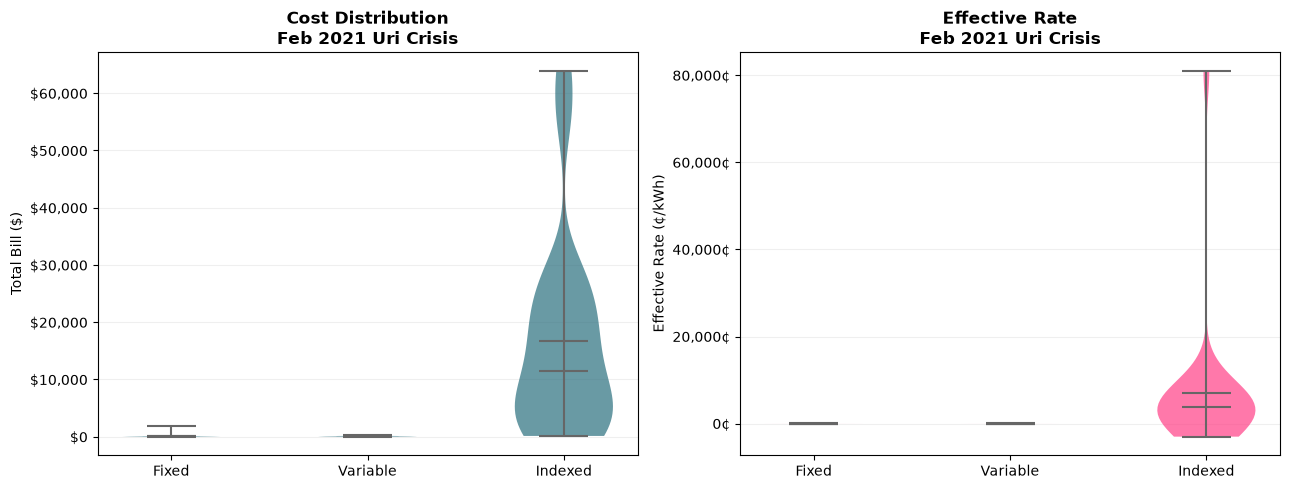

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

data_bills = [results_df[results_df["rate_type"] == rt]["total_bill"].values for rt in ["fixed", "variable", "indexed"]]
data_rates = [results_df[results_df["rate_type"] == rt]["effective_rate_c_kwh"].values for rt in ["fixed", "variable", "indexed"]]

parts1 = ax1.violinplot(data_bills, positions=[0, 1, 2], showmeans=True, showmedians=True)
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
    if partname in parts1:
        vp = parts1[partname]
        vp.set_edgecolor('#666666')  # Gray
        vp.set_linewidth(1.5)
for pc in parts1['bodies']:
    pc.set_facecolor(blogstyle.PALETTE[0])
    pc.set_alpha(0.7)
ax1.set_xticks([0, 1, 2])
ax1.set_xticklabels(["Fixed", "Variable", "Indexed"])
ax1.set_ylabel("Total Bill ($)")
ax1.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
blogstyle.title(ax1, "Cost Distribution", "Feb 2021 Uri Crisis")
ax1.grid(axis="y", alpha=0.2)
ax1.set_axisbelow(True)

parts2 = ax2.violinplot(data_rates, positions=[0, 1, 2], showmeans=True, showmedians=True)
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
    if partname in parts2:
        vp = parts2[partname]
        vp.set_edgecolor('#666666')  # Gray
        vp.set_linewidth(1.5)
for pc in parts2['bodies']:
    pc.set_facecolor(blogstyle.PALETTE[1])
    pc.set_alpha(0.7)
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(["Fixed", "Variable", "Indexed"])
ax2.set_ylabel("Effective Rate (¢/kWh)")
ax2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: f'{x:,.0f}¢'))
blogstyle.title(ax2, "Effective Rate", "Feb 2021 Uri Crisis")
ax2.grid(axis="y", alpha=0.2)
ax2.set_axisbelow(True)

plt.tight_layout()
fig.savefig("uri_cost_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Market Evolution: Crisis to Recovery

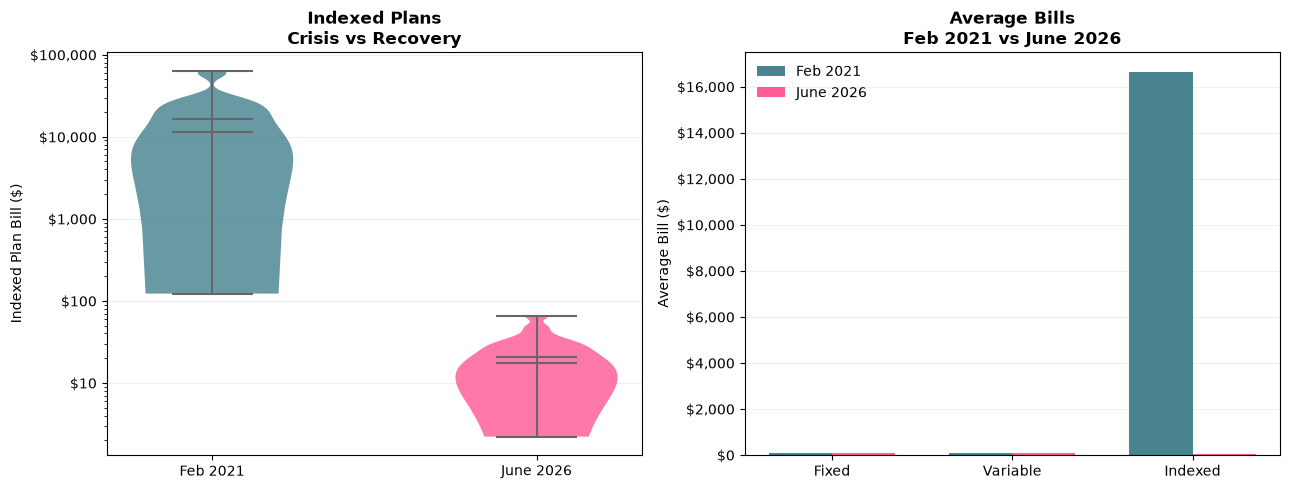

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

indexed_2021 = results_df[results_df["rate_type"] == "indexed"]["total_bill"].values
indexed_2026 = recent_results_df[recent_results_df["rate_type"] == "indexed"]["total_bill"].values if len(recent_results_df[recent_results_df["rate_type"] == "indexed"]) > 0 else np.array([0])

data_indexed = [indexed_2021, indexed_2026[indexed_2026 > 0] if len(indexed_2026[indexed_2026 > 0]) > 0 else indexed_2021]
parts = ax1.violinplot(data_indexed, positions=[0, 1], showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(blogstyle.PALETTE[i])
    pc.set_alpha(0.7)
for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
    if partname in parts:
        vp = parts[partname]
        vp.set_edgecolor('#666666')
        vp.set_linewidth(1.5)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(["Feb 2021", "June 2026"])
ax1.set_ylabel("Indexed Plan Bill ($)")
ax1.set_yscale("log")
ax1.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
blogstyle.title(ax1, "Indexed Plans", "Crisis vs Recovery")
ax1.grid(axis="y", alpha=0.2)
ax1.set_axisbelow(True)

x = np.arange(3)
width = 0.35

bills_2021 = [results_df[results_df["rate_type"] == rt]["total_bill"].mean() for rt in ["fixed", "variable", "indexed"]]
bills_2026 = [recent_results_df[recent_results_df["rate_type"] == rt]["total_bill"].mean() for rt in ["fixed", "variable", "indexed"]]

ax2.bar(x - width/2, bills_2021, width, label="Feb 2021", color=blogstyle.PALETTE[0], alpha=0.85)
ax2.bar(x + width/2, bills_2026, width, label="June 2026", color=blogstyle.PALETTE[1], alpha=0.85)

ax2.set_ylabel("Average Bill ($)")
ax2.set_xticks(x)
ax2.set_xticklabels(["Fixed", "Variable", "Indexed"])
ax2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
blogstyle.title(ax2, "Average Bills", "Feb 2021 vs June 2026")
ax2.legend(frameon=False)
ax2.grid(axis="y", alpha=0.2)
ax2.set_axisbelow(True)

plt.tight_layout()
fig.savefig("uri_market_evolution.png", dpi=150, bbox_inches="tight")
plt.show()